In [1]:
import h5py
import quimb as qu
import quimb.tensor as qtn
import numpy as np

import torch
from torch import optim
import tqdm
import cotengra as ctg

opti = ctg.ReusableHyperOptimizer(
    progbar=True,
    methods=['greedy'],
    reconf_opts={},
    max_repeats=32, 
    optlib='random',
    # directory=  # set this for persistent cache
)

### Read data

In [2]:
def read_data(data_name):
    with h5py.File("save_results/" + data_name + ".h5", "r") as f:
        keys = sorted(f.keys(), key=lambda x: int(x.split("_")[1]))
        print(keys)
        data = [np.transpose(f[key][:], (3,2,1,0)) for key in keys]

    return data

In [120]:
M1 = read_data("M1_a2_N6")
M2 = read_data("M2_a2_N6")

['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6']
['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6']


In [43]:
# for i in range(len(M1)):
    # print(M1[i].shape)

In [5]:
def array_to_lpdo(M1, tags):
    # convert input list of arrays to LPDO

    L = len(M1)

    inds = ('s0','e0','l0')
    first_tensor = M1[0][0,:,:,:]
    last_tensor = M1[-1][:,:,:,0]
    lpdo_1 = qtn.Tensor(data=first_tensor, inds=inds, tags=tags)

    for i in range(1, L):
        if i == L-1:
            inds = (f'l{i-1}', f's{i}', f'e{i}')
            current_tensor = qtn.Tensor(data=last_tensor, inds=inds, tags=tags)
        else:
            # bond, system, environment, bond
            inds = (f'l{i-1}', f's{i}', f'e{i}', f'l{i}')
            current_tensor = qtn.Tensor(data=M1[i], inds=inds, tags=tags)

        lpdo_1 = lpdo_1 & current_tensor

    return lpdo_1

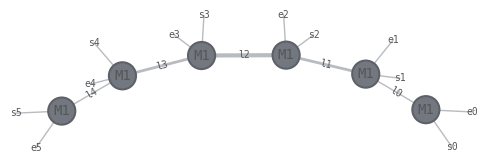

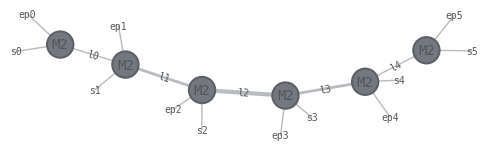

In [121]:
n = len(M1)
tags = ('M1',)
lpdo_1 = array_to_lpdo(M1, tags)
lpdo_1.draw(show_inds='all')

tags = ('M2',)
lpdo_2 = array_to_lpdo(M2, tags)
lpdo_2 = lpdo_2.H
for i in range (n):
    lpdo_2 = lpdo_2.reindex({f'e{i}':f'ep{i}'})
lpdo_2.draw(show_inds='all')

In [14]:
def add_ancilla(lpdo,label):
    
    L = len(lpdo_1.tensors)
    lpdo_acl = lpdo.copy()

    for i in range(L):
        prod = qtn.Tensor(np.array([1,0]),inds = (label+f'{i}',),tags = 'A')
        # prod.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
        
        # like direct product (outer product)
        lpdo_acl = lpdo_acl & prod

    return lpdo_acl

In [122]:
lpdo_1_acl = add_ancilla(lpdo_1,"a")
lpdo_2_acl = add_ancilla(lpdo_2,"ap")

## Use Torch

In [88]:
def brickwall_unitary(psi, n_apply, list_u3, depth, n_Qbit, val_iden = 0,rand = False,start_layer=0,is_acl=0):

    if n_Qbit==0: depth=1
    if n_Qbit==1: depth=1

    for r in range(depth):

        if (r+start_layer)%2==0:
            if is_acl==0:
                for i in range(0, n_Qbit, 2):
                    # print("U_e", i, i + 1, n_apply)

                    if rand == True:
                        G = qu.rand_uni(4, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(4,dtype=complex)+qu.rand_uni(4, dtype=complex)*val_iden
                
                    psi.gate_(G, (i, i + 1), tags={'U',f'G{n_apply}', f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

            elif is_acl==1:
                for i in range(0, n_Qbit, 4):

                    if rand == True:
                        G = qu.rand_uni(16, dtype=complex)
                    else:
                        G = qu.identity(16,dtype=complex)+qu.rand_uni(16, dtype=complex)*val_iden
                
                    psi.gate_(G, (i, i + 1,i+2,i+3), tags={'U',f'G{n_apply}', f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

        else:
            if is_acl==0:
                for i in range(0, n_Qbit-2, 2):
                    # print("U_o", i+1, i + 2, n_apply)
            
                    if rand == True:
                        G = qu.rand_uni(4, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(4,dtype=complex)+qu.rand_uni(4, dtype=complex)*val_iden

                    psi.gate_(G, (i+1, i + 2), tags={'U',f'G{n_apply}', f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

            elif is_acl == 1:
                for i in range(2, n_Qbit-2, 4):
                    # print("U_o", i, i + 1,i+2,i+3, n_apply)
            
                    if rand == True:
                        G = qu.rand_uni(16, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(16,dtype=complex)+qu.rand_uni(16, dtype=complex)*val_iden

                    psi.gate_(G, (i, i + 1,i+2,i+3), tags={'U',f'G{n_apply}', f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

    return n_apply, list_u3


def staircase_unitary(psi, n_apply, list_u3, depth, n_Qbit, val_iden = 0,rand = False,start_layer=0, is_acl=0):

    if n_Qbit==0: depth=1
    if n_Qbit==1: depth=1

    for r in range(depth):

        if (r+start_layer)%2==0:
            if is_acl == 0:
                for i in range(0, n_Qbit-1, 1):
                    # print("U_e", i, i + 1, n_apply)

                    if rand == True:
                        G = qu.rand_uni(4, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(4,dtype=complex)+qu.rand_uni(4, dtype=complex)*val_iden
                
                    psi.gate_(G, (i, i + 1), tags={'U',f'G{n_apply}',f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

            elif is_acl == 1:
                # acts on four sites, two system, two ancilla
                for i in range(0, n_Qbit-3, 2):
                    # print("U_e", i, i + 1, n_apply)

                    if rand == True:
                        G = qu.rand_uni(16, dtype=complex)
            
                    else:
                        G = qu.identity(16,dtype=complex)+qu.rand_uni(16, dtype=complex)*val_iden
                
                    psi.gate_(G, (i, i + 1, i+2, i+3), tags={'U',f'G{n_apply}',f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

        else:
            if is_acl == 0:
                for i in range(n_Qbit-1, 0, -1):
                    # print("U_o", i-1, i, n_apply)
            
                    if rand == True:
                        G = qu.rand_uni(4, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(4,dtype=complex)+qu.rand_uni(4, dtype=complex)*val_iden

                    psi.gate_(G, (i-1, i), tags={'U',f'G{n_apply}',f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

            elif is_acl == 1:
                for i in range(n_Qbit-1, 2, -2):
                    # print("U_o", i-1, i, n_apply)
            
                    if rand == True:
                        G = qu.rand_uni(16, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(16,dtype=complex)+qu.rand_uni(16, dtype=complex)*val_iden

                    psi.gate_(G, (i-3, i-2, i-1, i), tags={'U',f'G{n_apply}',f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

    return n_apply, list_u3

In [94]:
def qmps_f(L=16, in_depth=2, val_iden = 0, rand = True,start_layer = 0, framework='brickwall', is_acl=0):

    list_u3=[]
    n_apply=0
    psi = qtn.MPS_computational_state('0' * (L))
    for i in range(L):
        t = psi[i]
        indx = 'k'+str(i)
        t.modify(left_inds=[indx])

    for t in range(L):
        psi[t].modify(tags=[f"I{t}", "MPS"])

    if framework == 'brickwall':
        n_apply, list_u3=brickwall_unitary(psi, n_apply, list_u3, in_depth, L, val_iden = val_iden, rand =rand,start_layer=start_layer,is_acl=is_acl)
    elif framework == 'staircase':
        n_apply, list_u3=staircase_unitary(psi, n_apply, list_u3, in_depth, L, val_iden = val_iden, rand =rand,start_layer=start_layer,is_acl=is_acl)
    elif framework == 'mixed':
        n_apply, list_u3=brickwall_unitary(psi, n_apply, list_u3, in_depth, L, val_iden = val_iden, rand =rand,start_layer=start_layer,is_acl=is_acl)
        n_apply, list_u3=staircase_unitary(psi, n_apply, list_u3, in_depth, L, val_iden = val_iden, rand =rand,start_layer=start_layer,is_acl=is_acl)


    return psi.astype_('complex128')#, list_u3


def extract_unitary_circuit(psi_pqc, num_qubits):
    # only system qubits

    pqc = psi_pqc.tensors[num_qubits]
    for i in range (num_qubits+1,len(psi_pqc.tensors)):
        pqc = pqc&psi_pqc.tensors[i] #extrating the circuit part

    for i in range (num_qubits):
        pqc = pqc.reindex({f'k{i}':f'e{i}'})
        pqc = pqc.reindex({psi_pqc.tensors[i].inds[-1]:f'ep{i}'})

    return pqc


def extract_unitary_circuit_acl(psi_pqc, num_qubits):
    # for ancilla. num_qubits = 2*n

    pqc = psi_pqc.tensors[num_qubits]
    for i in range (num_qubits+1,len(psi_pqc.tensors)):
        pqc = pqc&psi_pqc.tensors[i] #extrating the circuit part

    for i in range (num_qubits):
        if (i%2):
            pqc = pqc.reindex({f'k{i}':f'e{i//2}'})
            pqc = pqc.reindex({psi_pqc.tensors[i].inds[-1]:f'ep{i//2}'})
        else:
            pqc = pqc.reindex({f'k{i}':f'a{i//2}'})
            pqc = pqc.reindex({psi_pqc.tensors[i].inds[-1]:f'ap{i//2}'})

    return pqc


def full_contraction(pqc, lpdo_1, lpdo_2, is_show=0):
    if is_show == 1:
        (lpdo_1 & lpdo_2 & pqc).draw(['U','M2','M1'])

    output = abs((lpdo_1 & lpdo_2 & pqc).contract(optimize=opti))
    
    # return torch.abs(output).real 
    return -output

In [95]:
class TNModel(torch.nn.Module):

    def __init__(self, pqc, lpdo_1, lpdo_2):
        super().__init__()

        # extract the raw arrays and a skeleton of the TN
        params, self.skeleton = qtn.pack(pqc)
        # n.b. you might want to do extra processing here to e.g. store each
        # parameter as a reshaped matrix (from left_inds -> right_inds), for
        # some optimizers, and for some torch parametrizations
        self.torch_params = torch.nn.ParameterDict({
            # torch requires strings as keys
            str(i): torch.nn.Parameter(initial)
            for i, initial in params.items()
        })
        self._loss_fn = lambda x: full_contraction(x, lpdo_1, lpdo_2)
        
    def forward(self):
        # convert back to original int key format
        params = {int(i): p for i, p in self.torch_params.items()}
        # reconstruct the TN with the new parameters
        pqc = qtn.unpack(params, self.skeleton)
        # isometrize and then return the energy
        return self._loss_fn(pqc.isometrize(method='exp'))

In [123]:
n = len(M1)
is_acl = 1
depth = 2  # this should be twice the depth in the note
framework = 'staircase'

if is_acl == 0:
    num_qubits = n # physical 
    psi_pqc = qmps_f(num_qubits, in_depth= depth, val_iden = 0.0,rand = True, framework=framework)
    pqc = extract_unitary_circuit(psi_pqc, num_qubits)
    full_contraction(pqc, lpdo_1, lpdo_2, is_show=0)

    pqc_torch = pqc.copy()
    lpdo_1_torch = lpdo_1.copy()
    lpdo_2_torch = lpdo_2.copy()

elif is_acl == 1:
    num_qubits = 2 * n # physical + ancilla 
    psi_pqc = qmps_f(num_qubits, in_depth= depth, val_iden = 0.0,rand = True, framework=framework,is_acl=1)
    pqc = extract_unitary_circuit_acl(psi_pqc, num_qubits)
    full_contraction(pqc, lpdo_1_acl, lpdo_2_acl, is_show=0)

    pqc_torch = pqc.copy()
    lpdo_1_torch = lpdo_1_acl.copy()
    lpdo_2_torch = lpdo_2_acl.copy()

In [124]:
pqc_torch.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
lpdo_1_torch.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
lpdo_2_torch.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))

model = TNModel(pqc_torch, lpdo_1_torch, lpdo_2_torch)
lr = 0.01
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=200, gamma=0.5)
num_steps = 1000
pbar = tqdm.tqdm(range(num_steps))
previous_loss = torch.inf
losses = []

print("Initial loss:", model.forward().item())

for step in pbar:
    optimizer.zero_grad()
    loss = model.forward()
    losses.append(loss.detach().numpy())
    loss.backward()
    optimizer.step()
    pbar.set_description(f"Loss={loss} - LR={lr}")
    if step > 100 and torch.abs(previous_loss - loss) < 1e-10:
        print("Early stopping loss difference is smaller than 1e-10")
        break
    previous_loss = loss.clone()
print(f'traning loss: {loss}')

Loss=-0.3270510229386005 - LR=0.01:   0%|          | 5/1000 [00:00<00:20, 48.01it/s] 

Initial loss: -0.0037764186714625307


Loss=-0.6181358199161433 - LR=0.01: 100%|██████████| 1000/1000 [00:17<00:00, 58.16it/s]

traning loss: -0.6181358199161433
